# Significance analysis with `pymer4` fitting LMMs

First, analysing the `given` prompt class since the demographic columns (`gender`, `occupation_category`, and `attended_uni`) are same for each `profile_id`.

This means I can model each outcome variable (metric) as depending on `model`, `temperature`, `demographics`.

```
## Summary of the pipeline
```
raw data (5 responses per cell)
* → aggregate to 1 row per prompt × model × temperature
* → encode categoricals, set reference levels
* → fit LMM per outcome variable
* → read fixed effects table
* → post-hoc pairwise comparisons with FDR correction
* → FDR correction across outcomes
* → check residuals

In [1]:
import sys
from pathlib import Path
root_dir = Path.cwd().parent
results_dir = root_dir / "data" / "olmo7b_results" / "v2"
sys.path.insert(0, str(root_dir))
from utils import load_json_data, save_dataframes

KEYWORD = "given"   # can otherwise be "assumed"
PREFIX = "metrics"  # can be None

loaded_dfs = load_json_data(results_dir, 
                            file_name_keyword=KEYWORD, 
                            prefix=PREFIX)
print(f"Loaded the following {KEYWORD} dfs:")
for k in loaded_dfs.keys():
    print(k)

Loaded the following given dfs:
metrics_olmo7b_base_given_all_temps
metrics_olmo7b_dpo_given_all_temps
metrics_olmo7b_rlvr_given_all_temps
metrics_olmo7b_sft_given_all_temps


In [2]:
for df in loaded_dfs.values():
    print(df.columns)
    break

Index(['model_key', 'profile_id', 'temperature', 'occupation_category',
       'attended_university', 'response_number', 'mean_entropy',
       'mean_entropy_nucleus', 'gender', 'self_bleu', 'semantic_div',
       'perplexity'],
      dtype='object')


First, a quick cell to combine all the given results with metrics into one json file.

In [3]:
import pandas as pd

# combine all dfs into one (vertically)
all_dfs = list(loaded_dfs.values())
combined_df = pd.concat(all_dfs).reset_index(drop=True)
print("Combined df columns:", combined_df.columns)
assert combined_df.shape[0] == sum(df.shape[0] for df in all_dfs), "Row count mismatch after concatenation"
print("Combined df shape:", combined_df.shape)
save_dataframes({"combined_metrics_olmo7b_given": combined_df}, results_dir)


Combined df columns: Index(['model_key', 'profile_id', 'temperature', 'occupation_category',
       'attended_university', 'response_number', 'mean_entropy',
       'mean_entropy_nucleus', 'gender', 'self_bleu', 'semantic_div',
       'perplexity'],
      dtype='object')
Combined df shape: (17600, 12)


In [4]:
nan_mask = combined_df.isna().any(axis=1)
nan_rows = combined_df.loc[nan_mask]

print(f"Rows with NaNs in any column: {nan_rows.shape[0]}")
print(nan_rows)

Rows with NaNs in any column: 0
Empty DataFrame
Columns: [model_key, profile_id, temperature, occupation_category, attended_university, response_number, mean_entropy, mean_entropy_nucleus, gender, self_bleu, semantic_div, perplexity]
Index: []


Now I will group the results and average their values for the outcome variables to avoid misrepresenting the "strength" of each value.

In [5]:
len(combined_df["profile_id"].unique())

176

In [19]:
# Aggregate: since each profile_id has 5 responses in this setup, average the 5 responses
# These are the variables that define a unique experimental cell (predictor variables)
group_cols = ["model_key", "profile_id", "temperature",
              "occupation_category", "gender", "attended_university"]

outcome_cols = ["mean_entropy", "mean_entropy_nucleus", 
                "self_bleu", "semantic_div", "perplexity"]

df = combined_df.groupby(group_cols)[outcome_cols].mean().reset_index()

# After this, each row = one unique prompt × model × temperature cell
# Expected number of rows: 176 prompts × 4 models × 5 temps = 3,520 rows
df.shape

(3520, 11)

Take care of categorical variables.

In [20]:
# Convert all columns with categorical info
cat_cols = ["model_key", "gender", "attended_university", "occupation_category"]
for col in cat_cols:
    df[col] = pd.Categorical(df[col])

from pandas.api.types import CategoricalDtype

df["model_key"] = pd.Categorical(df["model_key"], 
    categories=["base", "dpo", "rlvr", "sft"])

df["temperature"] = pd.Categorical(df["temperature"].astype(str),
    categories=["0.2", "0.5", "0.7", "1.0", "1.2"])

In [21]:
print(df["model_key"].unique().tolist())
print(df["temperature"].unique().tolist())

['base', 'dpo', 'rlvr', 'sft']
['0.2', '0.5', '0.7', '1.0', '1.2']


## Fit LMM!

In [55]:
from pymer4.models import Lmer

def fit_lmm(df, outcome: str) -> Lmer:
    """
    Fit a linear mixed-effects model for a single outcome variable.
    
    Fixed effects:
      - model_key * temperature  (main effects + interaction)
      - gender, attended_university        (demographic fixed effects)
    
    Random effects:
      - (1 | occupation_category)          (random intercept: account for occupation-level variance)
      - (1 | profile_id)           (random intercept: residual prompt-level variance)
    """
    
    formula = (
        f"{outcome} ~ model_key * temperature "
        f"+ gender + attended_university "
        f"+ (1 | occupation_category) + (1 | profile_id)"
    )
    
    model = Lmer(formula, data=df)
    
    # REML=True is standard for estimating variance components (random effects)
    # REML=False is needed if you want to compare models via likelihood ratio test
    model.fit(
        REML=True,
        summarize=False,
        factors={
            "model_key": ["base", "sft", "dpo", "rlvr"],
            "temperature": ["0.2", "0.5", "0.7", "1.0", "1.2"]
        }
    )
    
    return model


# Fit a model for each outcome
outcomes = ["mean_entropy", "mean_entropy_nucleus", "self_bleu", "semantic_div", "perplexity"]
models = {outcome: fit_lmm(df, outcome) for outcome in outcomes}

boundary (singular) fit: see help('isSingular') 



c:\Users\manth\GitHub\occupational_bias_llms\env\.pixi\envs\default\Lib\site-packages\pymer4\models\Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


boundary (singular) fit: see help('isSingular') 



c:\Users\manth\GitHub\occupational_bias_llms\env\.pixi\envs\default\Lib\site-packages\pymer4\models\Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


boundary (singular) fit: see help('isSingular') 



c:\Users\manth\GitHub\occupational_bias_llms\env\.pixi\envs\default\Lib\site-packages\pymer4\models\Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


boundary (singular) fit: see help('isSingular') 



c:\Users\manth\GitHub\occupational_bias_llms\env\.pixi\envs\default\Lib\site-packages\pymer4\models\Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
c:\Users\manth\GitHub\occupational_bias_llms\env\.pixi\envs\default\Lib\site-packages\pymer4\models\Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


In [57]:
m = models["mean_entropy"]
m.summary()

Linear mixed model fit by REML [’lmerMod’]
Formula: mean_entropy~model_key*temperature+gender+attended_university+(1|occupation_category)+(1|profile_id)

Family: gaussian	 Inference: parametric

Number of observations: 3520	 Groups: {'profile_id': 176.0, 'occupation_category': 44.0}

Log-likelihood: -1151.828 	 AIC: 2353.655

Random effects:

                            Name    Var    Std
profile_id           (Intercept)  0.000  0.000
occupation_category  (Intercept)  0.000  0.016
Residual                          0.109  0.330

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.156,0.104,0.207,0.026,3067.93,5.938,0.000,***
model_key1,0.025,-0.044,0.094,0.035,3455.00,0.710,0.478,
model_key2,0.013,-0.056,0.082,0.035,3455.00,0.379,0.705,
model_key3,-0.017,-0.086,0.052,0.035,3455.00,-0.473,0.637,
temperature1,0.288,0.219,0.357,0.035,3455.00,8.171,0.000,***
temperature2,0.563,0.494,0.632,0.035,3455.00,15.979,0.000,***
temperature3,1.555,1.486,1.624,0.035,3455.00,44.156,0.000,***
temperature4,4.313,4.244,4.382,0.035,3455.00,122.463,0.000,***
gendermale,0.004,-0.018,0.026,0.011,3455.00,0.345,0.730,
attended_universityyes,-0.019,-0.041,0.003,0.011,3455.00,-1.713,0.087,.


In [58]:
print(m.factors)

{'model_key': ['base', 'sft', 'dpo', 'rlvr'], 'temperature': ['0.2', '0.5', '0.7', '1.0', '1.2']}


### Post-hoc pairwise comparisons across models with FDR correction

In [74]:
m = models["semantic_div"]

# Pairwise comparisons between all model types, marginalising over temperature
posthoc = m.post_hoc(marginal_vars="model_key", p_adjust="BH")
posthoc

P-values adjusted by BH method for 6 comparisons


(  model_key  Estimate  2.5_ci  97.5_ci     SE      DF
 1      base     0.523   0.515    0.532  0.004  76.784
 2       dpo     0.438   0.429    0.446  0.004  76.784
 3      rlvr     0.417   0.408    0.426  0.004  76.784
 4       sft     0.545   0.536    0.553  0.004  76.784,
       Contrast  Estimate  2.5_ci  97.5_ci     SE      DF  T-stat  P-val  Sig
 1   base - dpo     0.086   0.076    0.095  0.004  3455.0  23.964    0.0  ***
 2  base - rlvr     0.106   0.097    0.116  0.004  3455.0  29.761    0.0  ***
 3   base - sft    -0.021  -0.031   -0.012  0.004  3455.0  -6.002    0.0  ***
 4   dpo - rlvr     0.021   0.011    0.030  0.004  3455.0   5.797    0.0  ***
 5    dpo - sft    -0.107  -0.116   -0.098  0.004  3455.0 -29.966    0.0  ***
 6   rlvr - sft    -0.128  -0.137   -0.118  0.004  3455.0 -35.763    0.0  ***)

In [75]:
# Pairwise comparison between all temperature values
posthoc_temp = m.post_hoc(marginal_vars="temperature", p_adjust="BH")
posthoc_temp

P-values adjusted by BH method for 10 comparisons


(  temperature  Estimate  2.5_ci  97.5_ci     SE      DF
 1         0.2     0.363   0.354    0.372  0.005  90.136
 2         0.5     0.437   0.428    0.446  0.005  90.136
 3         0.7     0.460   0.451    0.469  0.005  90.136
 4         1.0     0.516   0.507    0.525  0.005  90.136
 5         1.2     0.626   0.617    0.635  0.005  90.136,
                            Contrast  Estimate  2.5_ci  97.5_ci     SE      DF  \
 1   temperature0.2 - temperature0.5    -0.074  -0.085   -0.063  0.004  3455.0   
 2   temperature0.2 - temperature0.7    -0.097  -0.108   -0.086  0.004  3455.0   
 3   temperature0.2 - temperature1.0    -0.153  -0.164   -0.142  0.004  3455.0   
 4   temperature0.2 - temperature1.2    -0.263  -0.274   -0.252  0.004  3455.0   
 5   temperature0.5 - temperature0.7    -0.023  -0.034   -0.012  0.004  3455.0   
 6   temperature0.5 - temperature1.0    -0.079  -0.090   -0.068  0.004  3455.0   
 7   temperature0.5 - temperature1.2    -0.189  -0.200   -0.178  0.004  3455.0   
 

In [65]:
models["semantic_div"].coefs

,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.365945,0.352413,0.379477,0.006904,454.137566,53.004169,1.316865e-196,***
model_key1,-0.036693,-0.052345,-0.021040,0.007986,3455.000004,-4.594619,4.490327e-06,***
model_key2,-0.044451,-0.060103,-0.028799,0.007986,3455.000004,-5.566100,2.803581e-08,***
model_key3,0.049751,0.034099,0.065403,0.007986,3455.000004,6.229791,5.233023e-10,***
temperature1,0.127569,0.111917,0.143222,0.007986,3455.000005,15.974112,1.790708e-55,***
temperature2,0.126791,0.111139,0.142443,0.007986,3455.000005,15.876652,7.646222e-55,***
temperature3,0.194977,0.179325,0.210629,0.007986,3455.000005,24.414828,1.373418e-121,***
temperature4,0.311847,0.296195,0.327500,0.007986,3455.000006,39.049207,1.314420e-276,***
gendermale,0.007280,0.002331,0.012230,0.002525,3455.000007,2.882821,3.965645e-03,**
attended_universityyes,0.002782,-0.002167,0.007732,0.002525,3455.000007,1.101710,2.706647e-01,


### Correcting across model comparisons

In [40]:
from statsmodels.stats.multitest import multipletests

p_values = {
    "mean_entropy": models["mean_entropy"].coefs.loc["model_key1", "P-val"],
    "mean_entropy_nucleus": models["mean_entropy_nucleus"].coefs.loc["model_key1", "P-val"],
    # ... etc
}

p_vals_array = list(p_values.values())
reject, p_corrected, _, _ = multipletests(p_vals_array, method="fdr_bh")

for outcome, p_raw, p_adj in zip(p_values.keys(), p_vals_array, p_corrected):
    print(f"{outcome}: raw p={p_raw:.4f}, adjusted p={p_adj:.4f}")

mean_entropy: raw p=0.4780, adjusted p=0.5553
mean_entropy_nucleus: raw p=0.5553, adjusted p=0.5553


### Checking residuals with plot

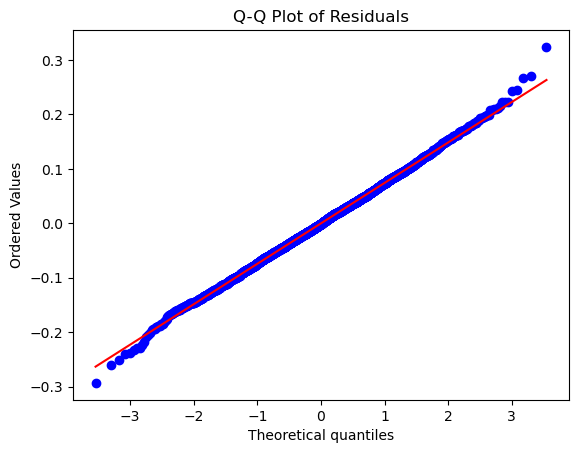

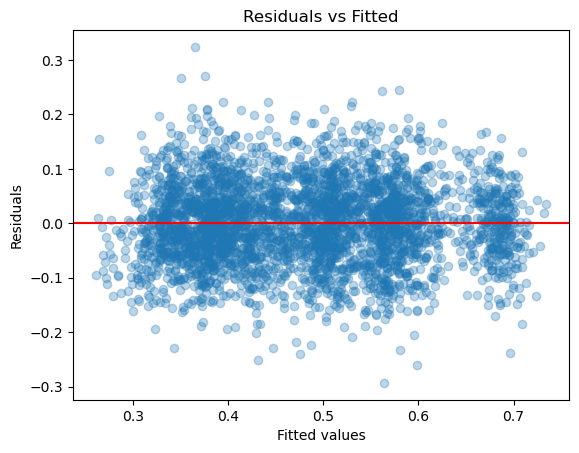

In [73]:
import matplotlib.pyplot as plt
import scipy.stats as stats

m = models["semantic_div"]
residuals = m.residuals

# 1. Residuals should be approximately normal
stats.probplot(residuals, plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# 2. Residuals should have constant variance (no funnel shape)
plt.scatter(m.fits, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()